<a href="https://colab.research.google.com/github/Akshaya24555/CodSoft/blob/main/ADlExp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Experiment - 1**



AIM:
To implement and evaluate a Multi-Layer Perceptron (MLP) classifier on the Iris dataset, and analyze model performance
using classification metrics.

PRE-REQUISITES:
1. Computer with Python Installed
2. Jupyter Notebook or Google Colab
3. Familiarity with NumPy, Pandas, Matplotlib, Seaborn, Scikit Learn
4. Knowledge on Machine Learning & Neural Networks

STEP 1: IMPORT THE BASIC LIBRARIES

In [3]:
#     24555A4209
# STEP 1: IMPORT THE BASIC LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

STEP 2: LOAD THE DATASET

In [4]:
df = pd.read_csv("iris.csv")

df.info()
df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sl      150 non-null    float64
 1   sw      150 non-null    float64
 2   pl      150 non-null    float64
 3   pw      150 non-null    float64
 4   class   150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sl,sw,pl,pw,class
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


STEP 3: APPLY PRE-PROCESSING & EDA

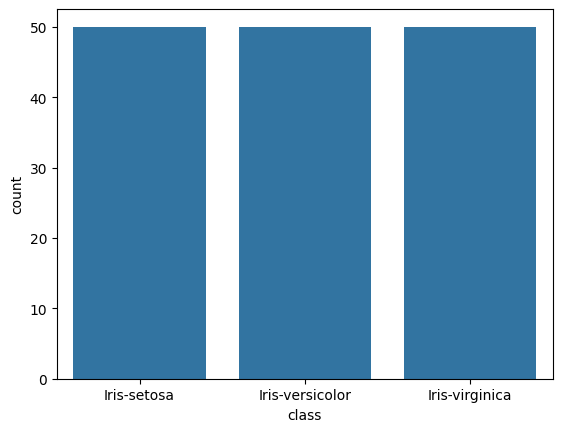

In [5]:

sns.countplot(x=df['class']);

Encoding Species Column using Integer Encoding

In [6]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['class'] = encoder.fit_transform(df['class'])
df.tail()

,sl,sw,pl,pw,class
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


Seperate X & y features

In [7]:
X = df.drop('class', axis=1)
y = df['class']

Standardize X Features using Standard Scaler

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)
scaled_X[1:7]

array([[-1.14301691, -0.1249576 , -1.33912459, -1.31297673],
       [-1.38535265,  0.33784833, -1.4527381 , -1.31297673],
       [-1.50652052,  0.10644536, -1.33912459, -1.31297673],
       [-1.02184904,  1.26346019, -1.33912459, -1.31297673],
       [-0.53717756,  1.95766909, -1.16870432, -1.05003079],
       [-1.50652052,  0.80065426, -1.33912459, -1.18150376]])

STEP 4: SPLIT DATA INTO TRAINING & TESTING DATASETS

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    scaled_X, y, test_size=0.3, random_state=7
)
 #Shape of the Splits
print(f"Train shape: {X_train.shape},{y_train.shape}, Test shape: {X_test.shape}, {y_test.shape}")

Train shape: (105, 4),(105,), Test shape: (45, 4), (45,)


STEP 5: BUILD & TRAIN MLP

In [10]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='tanh',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=200,
    random_state=7
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(activation='tanh', hidden_layer_sizes=(10, 10),
              learning_rate_init=0.01, random_state=7)

STEP 6: EVALUATE THE MODEL

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier

# Build and Train MLP (moved from VZTKslmFbSr3 to ensure model is defined)
model = MLPClassifier(
    hidden_layer_sizes=(11, 11),
    activation='tanh',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=200,
    random_state=7
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8888888888888888
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.87      0.81      0.84        16
           2       0.83      0.88      0.86        17

    accuracy                           0.89        45
   macro avg       0.90      0.90      0.90        45
weighted avg       0.89      0.89      0.89        45



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


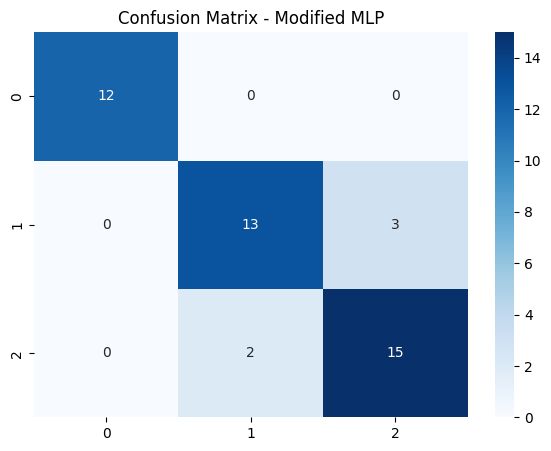

In [12]:
from sklearn.metrics import confusion_matrix # Added this line

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix - Modified MLP")
plt.show()

Visualize the Loss Curve

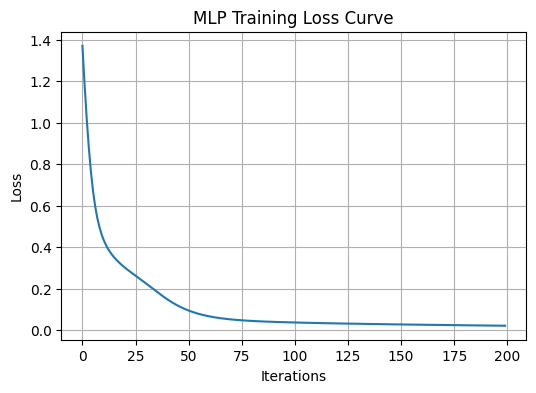

In [13]:
# Visualize Training Loss Curve
if hasattr(model, "loss_curve_"):
    plt.figure(figsize=(6,4))
    plt.plot(model.loss_curve_)
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.title("MLP Training Loss Curve")
    plt.grid(True)
    plt.show()

STEP 7: SAVE THE MODEL & SCALER FOR FURTHER USE

In [14]:
import joblib

joblib.dump(model, "iris_mlp_modified.joblib")
joblib.dump(scaler, "iris_scaler_modified.joblib")

['iris_scaler_modified.joblib']

STEP 8: GENERATE PREDICTIONS FOR NEW DATA

In [15]:
new_sample = np.array([[8.2, 4.8, 3.8, 2.8]])


In [16]:
new_sample_scaled = scaler.transform(new_sample)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [17]:
# Predict the class label
prediction = model.predict(new_sample_scaled)
prediction

array([2])

RESULT:
The Multi-Layer Perceptron (MLP) model was successfully implemented for the IRIS dataset. The prediction results for new
input samples confirmed that the model effectively classifies IRIS flower species based on sepal and petal measurements